# EDA

#### Step 1. Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2. Load Dataset

In [60]:
df = pd.read_csv("final_tumor_size_modeling_dataset.csv")

print(df.shape)
print(df.head())

(41, 29)
  participant_id   age sex      race handedness  \
0          RS001  31.0   M       NaN        NaN   
1          RS002  27.0   M       NaN        NaN   
2          RS003  44.0   M     White          R   
3          RS004  24.0   M  Hispanic          R   
4          RS005  36.0   M     White        NaN   

                            tumor_location  tumor_size_ml  \
0                        Rght frontal lobe           70.0   
1                        Left frontal lobe           11.7   
2  Left basal ganglia / Left temporal lobe            8.7   
3                        Left frontal lobe           56.2   
4     Left frontal lobe /Left frontal lobe            1.2   

                     tumor_pathology  has_motor_scan  has_language_scan  ...  \
0                  Oligodendroglioma               1                  0  ...   
1                   Oligoastrocytoma               1                  0  ...   
2                       Glioblastoma               1                  1  ... 

#### Step 3: Remove Failed MRI Scans

In [61]:
# Remove rows where target is missing
df = df.dropna(subset=["tumor_size_ml"])

print(df.shape)

(41, 29)


In [62]:
# Define target
y = df["tumor_size_ml"]

print(y.describe())

count     41.000000
mean      41.612195
std       48.691386
min        0.400000
25%        8.700000
50%       23.300000
75%       63.300000
max      207.000000
Name: tumor_size_ml, dtype: float64


In [63]:
print(df.select_dtypes(include="number").columns.tolist())

['age', 'tumor_size_ml', 'has_motor_scan', 'has_language_scan', 'mean_tSNR', 'mean_FD_mm', 'n_brain_voxels', 'n_scrubbed_volumes', 'n_volumes_after_scrub', 'tr_seconds', 'Mean Intensity', 'Median Intensity', 'Std Intensity', 'Nonzero Voxels', 'Nonzero Mean Intensity', 'Approx Brain Voxels', 'Approx Brain Volume ml', 'Approx Brain Mean Intensity', 'Simple SNR', 'Image Volume ml']


In [64]:
features = [
    "age",
    "has_motor_scan",
    "has_language_scan",
    "mean_tSNR",
    "mean_FD_mm",
    "n_brain_voxels",
    "n_scrubbed_volumes",
    "n_volumes_after_scrub",
    "tr_seconds",
    "Mean Intensity",
    "Median Intensity",
    "Std Intensity",
    "Nonzero Voxels",
    "Nonzero Mean Intensity",
    "Approx Brain Voxels",
    "Approx Brain Volume ml",
    "Approx Brain Mean Intensity",
    "Simple SNR",
    "Image Volume ml"
]

X = df[features]
y = df["tumor_size_ml"]

print(X.shape)
print(y.shape)

(41, 19)
(41,)


In [65]:
X.isnull().sum()

age                            0
has_motor_scan                 0
has_language_scan              0
mean_tSNR                      0
mean_FD_mm                     0
n_brain_voxels                 0
n_scrubbed_volumes             0
n_volumes_after_scrub          0
tr_seconds                     0
Mean Intensity                 0
Median Intensity               0
Std Intensity                  0
Nonzero Voxels                 0
Nonzero Mean Intensity         0
Approx Brain Voxels            0
Approx Brain Volume ml         0
Approx Brain Mean Intensity    0
Simple SNR                     0
Image Volume ml                0
dtype: int64

#### Step 4: Dataset Overview

In [66]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   participant_id               41 non-null     str    
 1   age                          41 non-null     float64
 2   sex                          41 non-null     str    
 3   race                         28 non-null     str    
 4   handedness                   26 non-null     str    
 5   tumor_location               41 non-null     str    
 6   tumor_size_ml                41 non-null     float64
 7   tumor_pathology              41 non-null     str    
 8   has_motor_scan               41 non-null     int64  
 9   has_language_scan            41 non-null     int64  
 10  tumor_hemisphere             41 non-null     str    
 11  tumor_category               41 non-null     str    
 12  outlier_flag                 41 non-null     bool   
 13  mean_tSNR                    41 n

#### Step 5: Missing Value Analysis

In [67]:
missing = df.isnull().sum()

print(missing[missing > 0])

race          13
handedness    15
dtype: int64


In [68]:
df = df.drop(columns=["Error Message"], errors="ignore")

print(df.isnull().sum()[df.isnull().sum() > 0])

race          13
handedness    15
dtype: int64


#### Step 6: Summary Statistics

In [69]:
summary_stats = df.describe()

print(summary_stats)

             age  tumor_size_ml  has_motor_scan  has_language_scan  mean_tSNR  \
count  41.000000      41.000000       41.000000          41.000000  41.000000   
mean   45.195122      41.612195        0.902439           0.853659  42.411057   
std    14.082293      48.691386        0.300406           0.357839  14.432534   
min    23.000000       0.400000        0.000000           0.000000  16.905000   
25%    33.000000       8.700000        1.000000           1.000000  33.346667   
50%    45.000000      23.300000        1.000000           1.000000  39.885000   
75%    56.000000      63.300000        1.000000           1.000000  47.295000   
max    71.000000     207.000000        1.000000           1.000000  82.210000   

       mean_FD_mm  n_brain_voxels  n_scrubbed_volumes  n_volumes_after_scrub  \
count   41.000000       41.000000           41.000000              41.000000   
mean     0.247783    51450.713415            0.662602             124.215447   
std      0.000268    20679.878

#### Step 7: Histogram of Target Variable

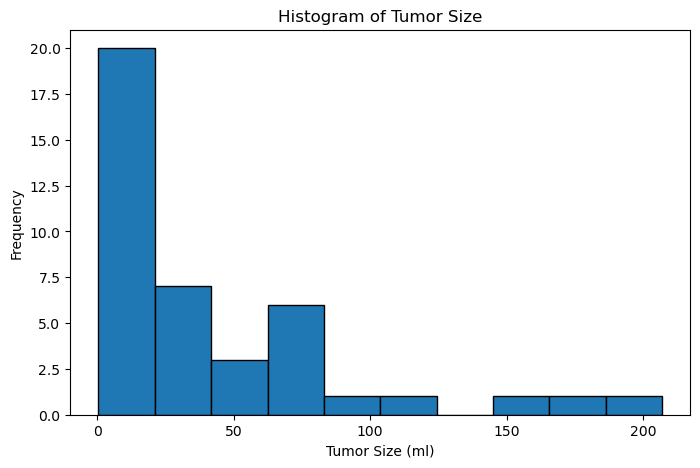

In [70]:
plt.figure(figsize=(8,5))

plt.hist(
    df["tumor_size_ml"],
    bins=10,
    edgecolor="black"
)

plt.title("Histogram of Tumor Size")
plt.xlabel("Tumor Size (ml)")
plt.ylabel("Frequency")
plt.show()

#### Step 8: Boxplot for Outlier Detection

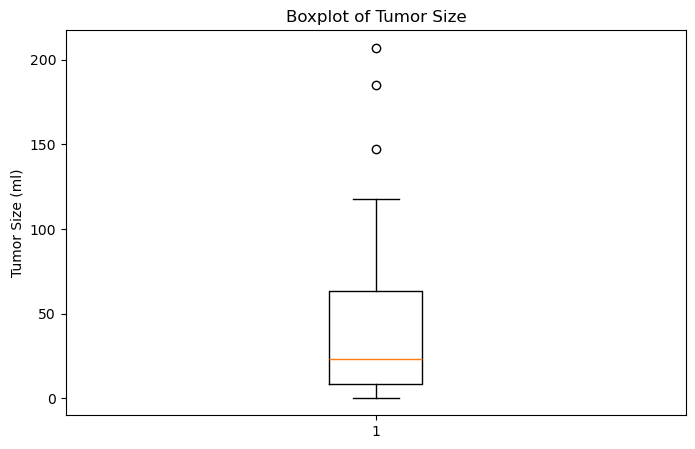

In [71]:
plt.figure(figsize=(8,5))

plt.boxplot(df["tumor_size_ml"])

plt.title("Boxplot of Tumor Size")
plt.ylabel("Tumor Size (ml)")
plt.show()

#### Step 9: Correlation Analysis with Target Variable

In [72]:
corr = df.corr(numeric_only=True)

corr_target = corr["tumor_size_ml"]

print(
    corr_target.sort_values(ascending=False).head(20)
)

tumor_size_ml                  1.000000
outlier_flag                   0.806546
tr_seconds                     0.389229
Nonzero Voxels                 0.268977
Approx Brain Voxels            0.248287
mean_tSNR                      0.201145
has_motor_scan                 0.111691
has_language_scan              0.105134
Median Intensity               0.086854
n_brain_voxels                 0.043062
Approx Brain Volume ml        -0.004648
Mean Intensity                -0.053057
Image Volume ml               -0.097460
Approx Brain Mean Intensity   -0.115220
Std Intensity                 -0.143109
age                           -0.148311
n_scrubbed_volumes            -0.173592
Simple SNR                    -0.179960
Nonzero Mean Intensity        -0.180188
n_volumes_after_scrub         -0.207350
Name: tumor_size_ml, dtype: float64


### Step 10: Correlation Heatmap

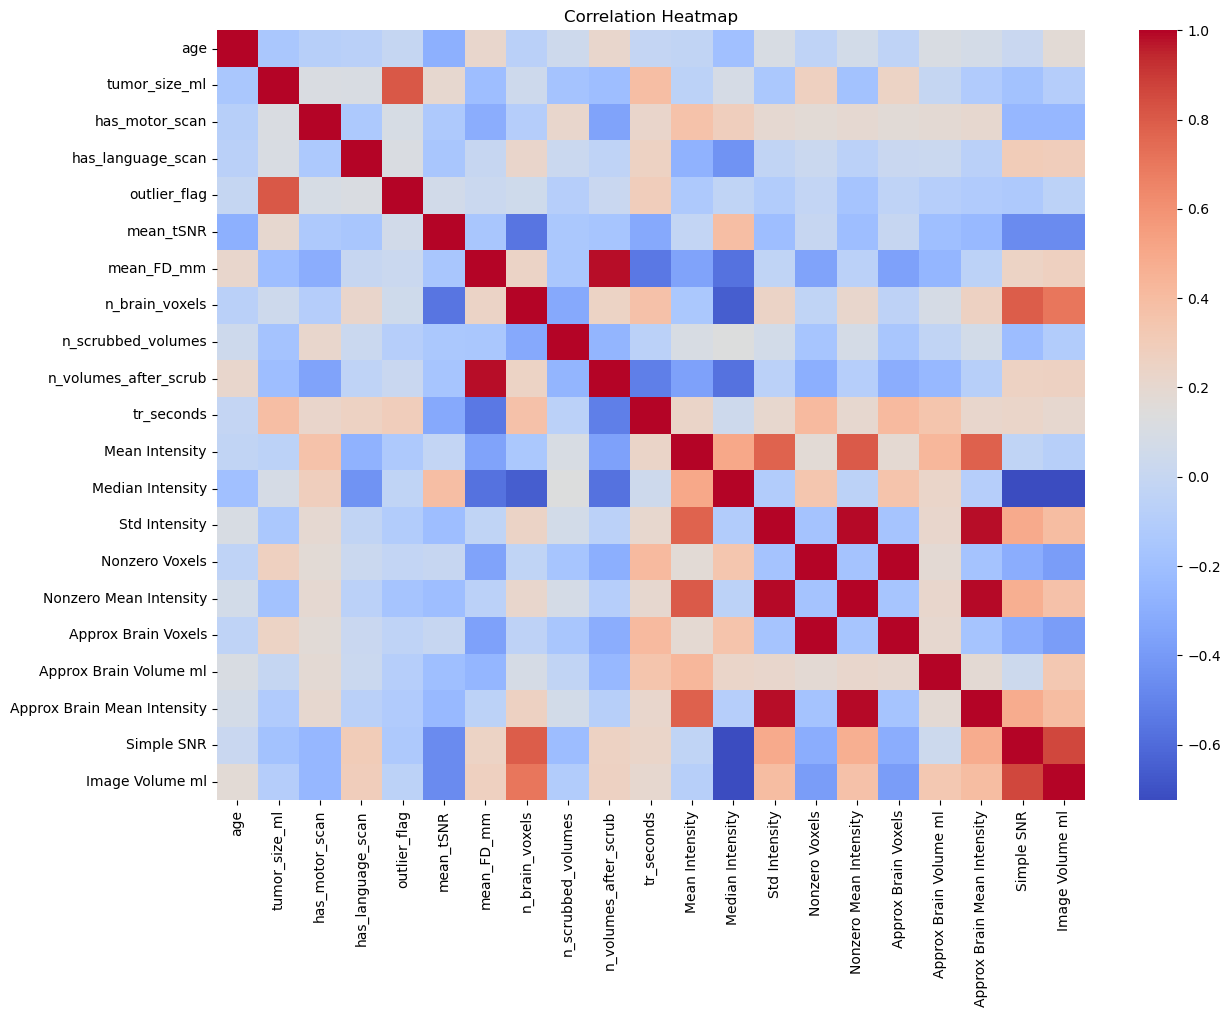

In [73]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

#### Step 11. Scatterplot of Strong Predictor

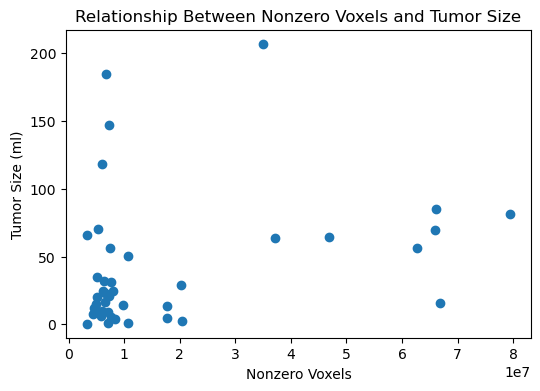

In [74]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["Nonzero Voxels"],
    df["tumor_size_ml"]
)

plt.xlabel("Nonzero Voxels")
plt.ylabel("Tumor Size (ml)")
plt.title("Relationship Between Nonzero Voxels and Tumor Size")
plt.show()

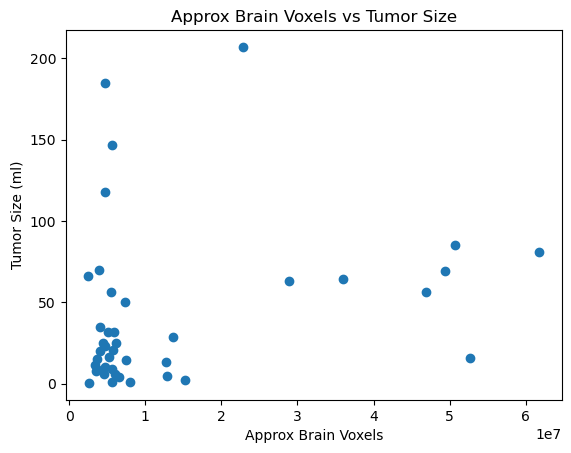

In [75]:
plt.scatter(
    df["Approx Brain Voxels"],
    df["tumor_size_ml"]
)

plt.xlabel("Approx Brain Voxels")
plt.ylabel("Tumor Size (ml)")
plt.title("Approx Brain Voxels vs Tumor Size")
plt.show()

#### Step 12:  Multicollinearity Check Using VIF


In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[
    [
        "Shape X",
        "Shape Y",
        "Shape Z",
        "Nonzero Voxels",
        "Approx Brain Voxels",
        "Background Voxels",
        "Mean Intensity",
        "Median Intensity"
    ]
]

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

KeyError: "['Shape X', 'Shape Y', 'Shape Z', 'Background Voxels'] not in index"

#### Step 13. LASSO Feature Selection

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])

lasso_model.fit(X_train, y_train)

pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print(mae_lasso, rmse_lasso, r2_lasso)

0.5189298966729541 0.523374409952448 -0.18372905472006584


/Users/nhann0409/miniforge3/envs/esi6630/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.311e-03, tolerance: 5.625e-04
  model = cd_fast.enet_coordinate_descent_gram(
/Users/nhann0409/miniforge3/envs/esi6630/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e-02, tolerance: 5.625e-04
  model = cd_fast.enet_coordinate_descent_gram(
/Users/nhann0409/miniforge3/envs/esi6630/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

X = df.select_dtypes(include="number").drop(
    columns=["tumor_size_ml", "outlier_flag"],
    errors="ignore"
)

y = df["tumor_size_ml"]

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000, random_state=42))
])

lasso.fit(X, y)

coef = pd.Series(
    lasso.named_steps["lasso"].coef_,
    index=X.columns
)

selected = coef[coef != 0]

print(selected.sort_values(key=abs, ascending=False))

tr_seconds                17.232457
mean_tSNR                  8.180827
Nonzero Mean Intensity    -4.156774
Simple SNR                -1.699166
n_scrubbed_volumes        -0.829551
dtype: float64


#### Step 14. Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    "age",
    "has_motor_scan",
    "has_language_scan",
    "mean_tSNR",
    "mean_FD_mm",
    "n_brain_voxels",
    "n_scrubbed_volumes",
    "n_volumes_after_scrub",
    "tr_seconds",
    "Mean Intensity",
    "Median Intensity",
    "Std Intensity",
    "Nonzero Voxels",
    "Nonzero Mean Intensity",
    "Approx Brain Voxels",
    "Approx Brain Volume ml",
    "Approx Brain Mean Intensity",
    "Simple SNR",
    "Image Volume ml"
]

X = df[features]
y = df["tumor_size_ml"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

MAE: 54.00773891200879
RMSE: 65.99346797984478
R²: -0.6081835482733455


In [ ]:
print(df["tumor_size_ml"].describe())

count     41.000000
mean      41.612195
std       48.691386
min        0.400000
25%        8.700000
50%       23.300000
75%       63.300000
max      207.000000
Name: tumor_size_ml, dtype: float64


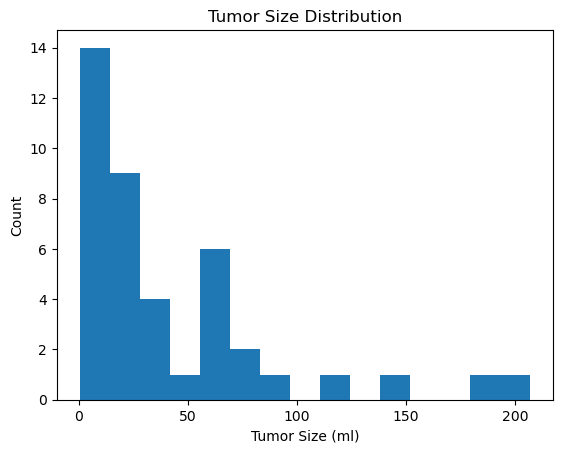

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["tumor_size_ml"], bins=15)
plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size (ml)")
plt.ylabel("Count")
plt.show()

In [ ]:
print(selected.sort_values(key=abs, ascending=False))

tr_seconds                17.232457
mean_tSNR                  8.180827
Nonzero Mean Intensity    -4.156774
Simple SNR                -1.699166
n_scrubbed_volumes        -0.829551
dtype: float64


#### Ridge Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

alphas = [0.01, 0.1, 1, 10, 100]

ridge = RidgeCV(alphas=alphas)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print("Best Alpha:", ridge.alpha_)
print("MAE:", mean_absolute_error(y_test, pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridge)))
print("R2:", r2_score(y_test, pred_ridge))

Best Alpha: 100.0
MAE: 44.72330835632754
RMSE: 66.98219092378456
R2: -0.6567325691609183


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 40.889909090909114
RMSE: 57.145058288757205
R2: -0.20584384920921805


In [ ]:
#feture importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                   Feature  Importance
8               tr_seconds    0.222387
12          Nonzero Voxels    0.139477
14     Approx Brain Voxels    0.127131
5           n_brain_voxels    0.074392
13  Nonzero Mean Intensity    0.066418
10        Median Intensity    0.058329
3                mean_tSNR    0.053554
0                      age    0.043104
18         Image Volume ml    0.040702
17              Simple SNR    0.032063


#### Tuned Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=1000,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

pred_rf_tuned = rf_tuned.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)

print(mae_rf_tuned, rmse_rf_tuned, r2_rf_tuned)

0.5054190160316963 0.5776531739669056 -0.4419880684528166


#### Model Compairison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mean_absolute_error(y_test, pred_ridge),
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_score(y_test, pred_ridge),
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,54.007739,65.993468,-0.608184
1,Ridge Regression,44.723308,66.982191,-0.656733
2,Random Forest,40.889909,57.145058,-0.205844


#### Decision Tree Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, pred_tree))
r2_tree = r2_score(y_test, pred_tree)

print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

MAE: 55.34465240641712
RMSE: 79.49244791623688
R2: -1.333379910179775


In [ ]:
# feture importance for decision tree
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by="Importance",
    ascending=False
)

print(tree_importance.head(10))

                        Feature  Importance
14          Approx Brain Voxels    0.371777
8                    tr_seconds    0.271499
5                n_brain_voxels    0.263445
3                     mean_tSNR    0.056255
0                           age    0.021129
7         n_volumes_after_scrub    0.011859
12               Nonzero Voxels    0.004036
17                   Simple SNR    0.000000
16  Approx Brain Mean Intensity    0.000000
15       Approx Brain Volume ml    0.000000


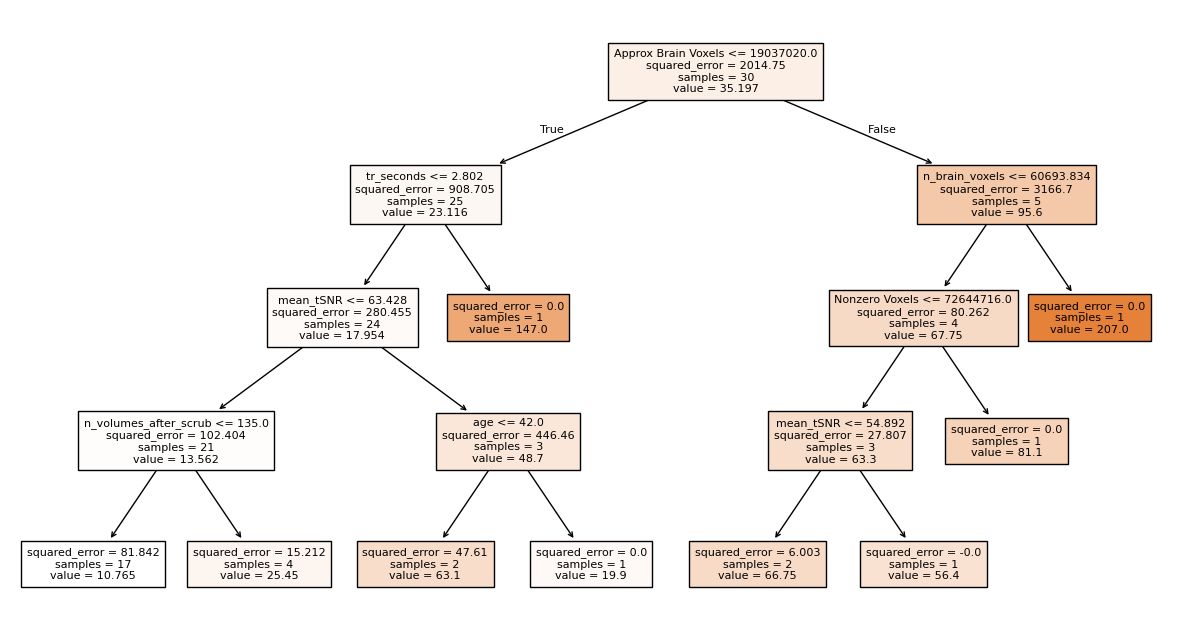

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.show()

#### PCA

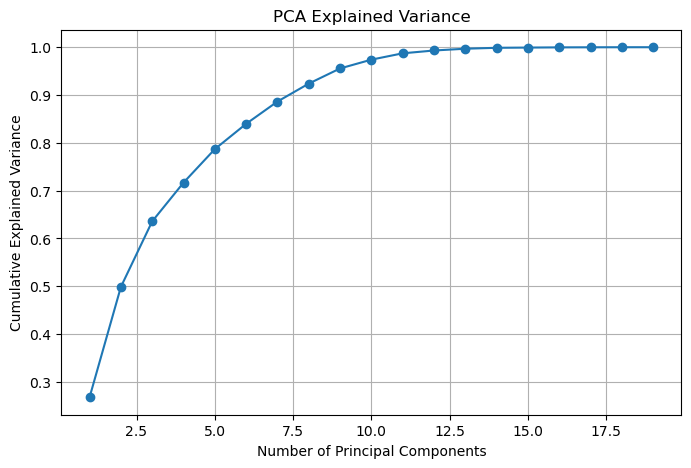

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_explained)+1),
    cum_explained,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [ ]:
print(pd.DataFrame({
    "PC": range(1, len(explained)+1),
    "Variance Explained": explained,
    "Cumulative Variance": cum_explained
}).head(10))

   PC  Variance Explained  Cumulative Variance
0   1            0.267909             0.267909
1   2            0.230769             0.498678
2   3            0.137128             0.635806
3   4            0.080952             0.716758
4   5            0.070097             0.786854
5   6            0.052938             0.839793
6   7            0.046595             0.886388
7   8            0.037496             0.923883
8   9            0.031729             0.955613
9  10            0.018409             0.974022


#### Classification

In [ ]:
median_size = df["tumor_size_ml"].median()

df["large_tumor"] = (
    df["tumor_size_ml"] > median_size
).astype(int)

print(df["large_tumor"].value_counts())

large_tumor
0    21
1    20
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_class = X
y_class = df["large_tumor"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.25,
    random_state=42
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=5000))
])

logit.fit(X_train, y_train)

pred = logit.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.45454545454545453
[[3 1]
 [5 2]]


#### GLM

In [ ]:
import statsmodels.api as sm

X_glm = sm.add_constant(X)

glm = sm.GLM(
    y,
    X_glm,
    family=sm.families.Gaussian()
)

results = glm.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          tumor_size_ml   No. Observations:                   41
Model:                            GLM   Df Residuals:                       21
Model Family:                Gaussian   Df Model:                           19
Link Function:               Identity   Scale:                          1768.7
Method:                          IRLS   Log-Likelihood:                -197.76
Date:                Tue, 23 Jun 2026   Deviance:                       37142.
Time:                        17:09:49   Pearson chi2:                 3.71e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6235
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    "Metric": [
        f"R² = {r2_lr:.3f}",
        f"R² = {-0.657:.3f}",
        f"R² = {r2_tree:.3f}",
        f"R² = {r2_rf:.3f}",
        f"Accuracy = {0.455:.3f}"
    ]
})

results

,Model,Metric
0,Linear Regression,R² = -0.608
1,Ridge Regression,R² = -0.657
2,Decision Tree,R² = -1.333
3,Random Forest,R² = -0.206
4,Logistic Regression,Accuracy = 0.455
